# Hierarchical CRNN + embedding SMOTE, v2 -- fine-tuned backbone, corrected split, per-class oversampling

`model_crnn_hierarchical_synthesis.ipynb` (v1) got `focal_aware` recall to 81% by relaxing LOSO
to an event-level split and applying SMOTE on **Phase A's frozen, detection-only embeddings**.
`focal_to_bilateral_tonic_clonic` (FBTC) stayed at 0% recall in every real and control run --
the model never once predicted it, despite having a comparable number of post-SMOTE training
points to `focal_aware`. v1's own notes named the likely cause and the fix: *"the frozen
backbone's embedding space ... doesn't linearly separate tonic-clonic windows ... Fine-tuning
the last conv block + LSTM ... on the SMOTE-balanced set ... is the natural next step."*

This notebook does exactly that, plus two more things v1's own notes flagged as untested:

1. **A corrected event-level split.** v1's split allocator (`if cum < target_test: append`)
   stops the instant it crosses the target, so a single oversized event can overshoot it by a
   wide margin. That's exactly what happened: `TEST_FRAC=0.3` produced a **1,405/419 test/train
   split (77%/23%)** -- inverted from the intent, and starving the classifier (and now the
   backbone fine-tune) of real training signal. Fixed here with a largest-first, deficit-driven
   greedy allocator (classic balanced-partition heuristic) that actually lands near 70/30.
2. **Backbone fine-tuning before embedding extraction.** Same weight-transfer pattern Phase B
   already validated in `model_crnn_hierarchical.ipynb` (`FREEZE_CONV_BLOCKS=2`, inverse-sqrt
   class-weighted `CrossEntropyLoss`, `>=` checkpoint selection) -- but on the corrected,
   larger real-window train split instead of a LOSO fold, and on raw signal so the backbone
   actually learns subtype-relevant structure instead of only ever seeing detection labels.
3. **Per-class SMOTE oversample ratio**, so FBTC isn't forced to share `focal_aware`'s ratio.

Everything else -- event-level (not LOSO) protocol, the adversarial control, the `>=`
checkpoint rule, the fresh classifier head trained on embeddings -- stays as v1 defined it, so
results stay comparable. The same honesty rule applies: this is still not a LOSO number and
still doesn't establish generalization to a genuinely new patient -- it answers "how much of
all three classes can be recovered for the patients already in this cohort."


## Config

In [1]:
import copy
import json
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "white"

# ---- paths --------------------------------------------------------------------------
WIN_ROOT = Path("../data/harmonized/windows")
PHASE_A_CKPT = Path("../checkpoints/crnn_hierarchical/phase_a_backbone_detector.pt")
CKPT_DIR = Path("../checkpoints/crnn_hierarchical_smote_v2")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 20260803                      # same seed as every other notebook in this repo

# ---- split ------------------------------------------------------------------------------
TEST_FRAC = 0.3                      # per-class, allocated by window count via balanced greedy assignment
CONTROL_WINDOWS_PER_PATIENT = 150    # matches v1 / Stage 2 / Phase B's adversarial control size

# ---- backbone (must match model_crnn_hierarchical.ipynb's Phase A exactly) ----------------
CNN_WIDTH = 32
RNN_HIDDEN = 64
RNN_LAYERS = 1
CNN_DROPOUT = 0.1
RNN_DROPOUT = 0.2
PHASE_A_HEAD_DROPOUT = 0.35          # only used to instantiate the checkpoint's shape

# ---- backbone fine-tuning (new in v2 -- same recipe Phase B validated for LOSO) -----------
FREEZE_CONV_BLOCKS = 2               # freeze first 2 of 4 conv blocks (Phase B's recipe); see the closing
                                      # Notes cell for why FREEZE_CONV_BLOCKS=3 was tried and rejected despite
                                      # higher headline accuracy
FT_HEAD_DROPOUT = 0.5
FT_LR = 3e-4
FT_WEIGHT_DECAY = 3e-3
FT_BATCH_SIZE = 32
FT_MAX_EPOCHS = 60
FT_PATIENCE = 10
FT_MIN_EPOCHS = 12
FT_VAL_FRAC = 0.15                   # stratified holdout carved from the real train split

# ---- SMOTE (per-class ratio, new in v2) ----------------------------------------------------
# v1 found MAX_OVERSAMPLE_RATIO=8 (near full parity) collapses test accuracy via prior mismatch,
# and that focal_aware got real signal at ratio 3 while focal_to_bilateral_tonic_clonic (FBTC)
# did not, despite a comparable post-SMOTE count. Giving FBTC extra headroom independently
# tests whether it was starved for synthetic diversity or whether (as v1 suspected) it's an
# embedding-separability problem the backbone fine-tune above should fix first.
OVERSAMPLE_RATIO = {"focal_aware": 3, "focal_to_bilateral_tonic_clonic": 5}
SMOTE_K_NEIGHBORS = 5

# ---- classifier head (trained on precomputed embeddings) ----------------------------------
HEAD_HIDDEN = 64
HEAD_DROPOUT = 0.5
HEAD_LR = 1e-3
HEAD_WEIGHT_DECAY = 3e-3
HEAD_BATCH_SIZE = 64
HEAD_MAX_EPOCHS = 300
HEAD_PATIENCE = 25
HEAD_MIN_EPOCHS = 30
INTERNAL_VAL_FRAC = 0.15             # carved out of the TRAIN split only, stratified

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))


device: cuda (NVIDIA GeForce RTX 5060 Ti)


## Data

Same harmonized windows every other notebook uses. `S2` is Siena's subtype-labelled seizure
windows; `S1` is only used here to build the adversarial control (interictal windows).

In [2]:
S2 = pd.read_parquet(WIN_ROOT / "stage2_windows.parquet")
S1 = pd.read_parquet(WIN_ROOT / "stage1_windows.parquet")
MANIFEST = json.loads((WIN_ROOT / "manifest.json").read_text())

N_CH = MANIFEST["n_channels"]
N2_TIMEPOINTS = int(round(MANIFEST["stage2"]["window_s"] * MANIFEST["sfreq"]))
CLASS_NAMES = MANIFEST["stage2"]["class_names"]
CLASS_TO_IDX = MANIFEST["stage2"]["class_to_idx"]
SUBTYPE_BY_PATIENT = MANIFEST["subtype_by_patient"]
N_CLASSES = len(CLASS_NAMES)
stage2_patients = sorted(S2.subject.unique())

print(f"{len(S2):,} seizure windows | {S2.event_id.nunique()} events | {len(stage2_patients)} patients")
print("\nevents per class:"); print(S2.groupby("subtype").event_id.nunique())
print("\nwindows per class:"); print(S2.subtype.value_counts())


1,824 seizure windows | 45 events | 13 patients

events per class:
subtype
focal_aware                         4
focal_impaired_awareness           32
focal_to_bilateral_tonic_clonic     9
Name: event_id, dtype: int64

windows per class:
subtype
focal_impaired_awareness           1655
focal_to_bilateral_tonic_clonic     124
focal_aware                          45
Name: count, dtype: int64


### Event-level stratified split -- corrected allocator

v1's allocator appended events to the test side until `cum >= target_test`, then stopped. With
highly variable event sizes (a single seizure can carry hundreds of overlapping windows), that
overshoots badly and unpredictably: it produced a 1,405/419 (77%/23%) test/train split against
a stated `TEST_FRAC=0.3`. The fix here is a largest-first, deficit-driven greedy assignment
(classic balanced-partition heuristic): sort each class's events by size descending, and place
each one on whichever side is currently furthest below its own target share. This can't
guarantee an exact 70/30 split when event sizes are lumpy, but it converges far closer than
"stop the moment you cross the line," and it can't wildly invert the ratio the way v1's did.

In [3]:
def event_stratified_split_v2(df, test_frac, seed):
    train_events, test_events = set(), set()
    for subtype, g in df.groupby("subtype"):
        ev = g.groupby("event_id").size().rename("n_windows").reset_index()
        ev = ev.sample(frac=1, random_state=seed).reset_index(drop=True)          # seeded shuffle (tie-break)
        ev = ev.sort_values("n_windows", ascending=False, kind="stable").reset_index(drop=True)
        total = int(ev.n_windows.sum())
        target_test = total * test_frac
        target_train = total - target_test
        cum_train, cum_test = 0, 0
        train_ids, test_ids = [], []
        for row in ev.itertuples(index=False):
            test_deficit = target_test - cum_test
            train_deficit = target_train - cum_train
            if test_deficit >= train_deficit:
                test_ids.append(row.event_id); cum_test += row.n_windows
            else:
                train_ids.append(row.event_id); cum_train += row.n_windows
        if not test_ids:
            test_ids = [train_ids.pop()]
        if not train_ids:
            train_ids = [test_ids.pop()]
        train_events.update(train_ids)
        test_events.update(test_ids)
    assert not (train_events & test_events), "event leakage across splits"
    return train_events, test_events

train_events, test_events = event_stratified_split_v2(S2, TEST_FRAC, SEED)
train_df = S2[S2.event_id.isin(train_events)].reset_index(drop=True)
test_df = S2[S2.event_id.isin(test_events)].reset_index(drop=True)

print(f"train: {len(train_events)} events | {len(train_df):,} windows  "
      f"({len(train_df) / len(S2):.1%} of all windows, target {1 - TEST_FRAC:.0%})")
print(train_df.subtype.value_counts())
print(f"\ntest: {len(test_events)} events | {len(test_df):,} windows  ({len(test_df) / len(S2):.1%})")
print(test_df.subtype.value_counts())
print(f"\npatients contributing to both train and test: "
      f"{sorted(set(train_df.subject) & set(test_df.subject))}")
print(f"\nfor reference, v1's (uncorrected) split gave 419 train / 1,405 test windows -- "
      f"inverted from TEST_FRAC={TEST_FRAC}")


train: 24 events | 1,274 windows  (69.8% of all windows, target 70%)
subtype
focal_impaired_awareness           1158
focal_to_bilateral_tonic_clonic      87
focal_aware                          29
Name: count, dtype: int64

test: 21 events | 550 windows  (30.2%)
subtype
focal_impaired_awareness           497
focal_to_bilateral_tonic_clonic     37
focal_aware                         16
Name: count, dtype: int64

patients contributing to both train and test: ['PN00', 'PN03', 'PN05', 'PN09', 'PN10', 'PN12', 'PN14', 'PN17']

for reference, v1's (uncorrected) split gave 419 train / 1,405 test windows -- inverted from TEST_FRAC=0.3


## Backbone -- loaded from Phase A, then fine-tuned (not frozen)

v1 froze this entirely. v2 loads the same Phase A checkpoint but unfreezes the last 2 conv
blocks + LSTM + attention (`FREEZE_CONV_BLOCKS=2`, identical to Phase B's weight-transfer
recipe in `model_crnn_hierarchical.ipynb`) and fine-tunes on real subtype windows only, with
inverse-sqrt class-weighted `CrossEntropyLoss` -- the same imbalance handling Phase B's LOSO
folds already validated, just applied to the (corrected) event-level train split instead of a
LOSO fold.

In [4]:
class CRNNBackbone(nn.Module):
    def __init__(self, n_channels=18, cnn_width=32, rnn_hidden=64, rnn_layers=1,
                 cnn_dropout=0.1, rnn_dropout=0.2):
        super().__init__()

        def block(c_in, c_out, k, stride):
            return nn.Sequential(
                nn.Conv1d(c_in, c_out, k, stride=stride, padding=k // 2, bias=False),
                nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.Dropout(cnn_dropout),
            )

        self.conv = nn.ModuleList([
            block(n_channels, cnn_width, 63, 2),
            block(cnn_width, cnn_width * 2, 31, 2),
            block(cnn_width * 2, cnn_width * 4, 15, 2),
            block(cnn_width * 4, cnn_width * 4, 7, 2),
        ])
        self.rnn = nn.LSTM(cnn_width * 4, rnn_hidden, num_layers=rnn_layers, batch_first=True,
                            bidirectional=True, dropout=rnn_dropout if rnn_layers > 1 else 0.0)
        self.attn = nn.Sequential(nn.Linear(rnn_hidden * 2, rnn_hidden), nn.Tanh(),
                                   nn.Linear(rnn_hidden, 1))
        self.out_dim = rnn_hidden * 2

    def forward(self, x):
        f = x
        for block in self.conv:
            f = block(f)
        f = f.transpose(1, 2)
        seq, _ = self.rnn(f)
        weights = torch.softmax(self.attn(seq).squeeze(-1), dim=1)
        return torch.bmm(weights.unsqueeze(1), seq).squeeze(1)


class HierarchicalCRNN(nn.Module):
    # Only used to load the Phase A checkpoint's state_dict shape; detect_head is discarded.
    def __init__(self, n_channels=18, n_subtypes=3, cnn_width=32, rnn_hidden=64, rnn_layers=1,
                 cnn_dropout=0.1, rnn_dropout=0.2, head_dropout=0.35):
        super().__init__()
        self.backbone = CRNNBackbone(n_channels, cnn_width, rnn_hidden, rnn_layers,
                                      cnn_dropout, rnn_dropout)
        d = self.backbone.out_dim

        def head(n_out):
            return nn.Sequential(nn.Linear(d, d // 2), nn.ReLU(inplace=True),
                                  nn.Dropout(head_dropout), nn.Linear(d // 2, n_out))

        self.detect_head = head(1)
        self.subtype_head = head(n_subtypes)

    def forward(self, x, head="detect"):
        ctx = self.backbone(x)
        return self.detect_head(ctx).squeeze(-1) if head == "detect" else self.subtype_head(ctx)


ckpt_a = torch.load(PHASE_A_CKPT, map_location=DEVICE, weights_only=False)


def make_finetune_model():
    m = HierarchicalCRNN(N_CH, N_CLASSES, CNN_WIDTH, RNN_HIDDEN, RNN_LAYERS,
                          CNN_DROPOUT, RNN_DROPOUT, FT_HEAD_DROPOUT).to(DEVICE)
    backbone_state = {k: v for k, v in ckpt_a["model_state"].items() if k.startswith("backbone.")}
    missing, unexpected = m.load_state_dict(backbone_state, strict=False)
    assert all(k.startswith(("detect_head.", "subtype_head.")) for k in missing), \
        f"unexpected missing keys after backbone transfer: {missing}"
    for i, block in enumerate(m.backbone.conv):
        requires_grad = i >= FREEZE_CONV_BLOCKS
        for p in block.parameters():
            p.requires_grad = requires_grad
    return m


_probe = make_finetune_model()
n_trainable = sum(p.numel() for p in _probe.parameters() if p.requires_grad)
n_frozen = sum(p.numel() for p in _probe.parameters() if not p.requires_grad)
print(f"backbone loaded from Phase A checkpoint (epoch {ckpt_a['epoch']}, val AUROC {ckpt_a['val_auc']:.4f})")
print(f"fine-tune model: {n_trainable:,} trainable params, {n_frozen:,} frozen (blocks 0-{FREEZE_CONV_BLOCKS - 1}) params")
del _probe


backbone loaded from Phase A checkpoint (epoch 5, val AUROC 0.8164)
fine-tune model: 362,501 trainable params, 99,968 frozen (blocks 0-1) params


### Raw-window dataset (for fine-tuning) and stratified internal validation

In [5]:
class RawWindowDataset(Dataset):
    def __init__(self, df, n_timepoints, y):
        self.rows = df.reset_index(drop=True)
        self.n_timepoints = n_timepoints
        self.y = y
        self._cache = {}

    def __len__(self):
        return len(self.rows)

    def _file(self, path):
        f = self._cache.get(path)
        if f is None:
            f = h5py.File(path, "r")
            self._cache[path] = f
        return f

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        sig = self._file(row.path)["signal"]
        start = int(row.start)
        end = min(start + self.n_timepoints, sig.shape[1])
        w = sig[:, start:end].astype(np.float32)
        if w.shape[1] < self.n_timepoints:
            w = np.pad(w, ((0, 0), (0, self.n_timepoints - w.shape[1])), mode="edge")
        mu = w.mean(axis=1, keepdims=True)
        sd = w.std(axis=1, keepdims=True) + 1e-6
        w = (w - mu) / sd
        return torch.from_numpy(w), torch.tensor(self.y[idx], dtype=torch.long)


def stratified_holdout(y, frac, seed):
    rng = np.random.default_rng(seed)
    val_idx = []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        n_val = max(1, int(round(len(idx) * frac)))
        val_idx.extend(rng.choice(idx, size=n_val, replace=False))
    val_mask = np.zeros(len(y), dtype=bool)
    val_mask[val_idx] = True
    return val_mask


y_train_full = train_df.subtype.map(CLASS_TO_IDX).to_numpy()
ft_val_mask = stratified_holdout(y_train_full, FT_VAL_FRAC, SEED)
ft_train_df = train_df[~ft_val_mask].reset_index(drop=True)
ft_val_df = train_df[ft_val_mask].reset_index(drop=True)
y_ft_train = y_train_full[~ft_val_mask]
y_ft_val = y_train_full[ft_val_mask]

print(f"fine-tune train: {len(ft_train_df)} windows | fine-tune val: {len(ft_val_df)} windows")
print("fine-tune train class counts:", {CLASS_NAMES[c]: int((y_ft_train == c).sum()) for c in range(N_CLASSES)})
print("fine-tune val class counts  :", {CLASS_NAMES[c]: int((y_ft_val == c).sum()) for c in range(N_CLASSES)})


fine-tune train: 1083 windows | fine-tune val: 191 windows


fine-tune train class counts: {'focal_aware': 25, 'focal_impaired_awareness': 984, 'focal_to_bilateral_tonic_clonic': 74}
fine-tune val class counts  : {'focal_aware': 4, 'focal_impaired_awareness': 174, 'focal_to_bilateral_tonic_clonic': 13}


### Fine-tuning loop

**Checkpoint selection uses macro-averaged per-class validation accuracy, not raw val_acc.**
A first version of this cell selected on raw `val_acc` and it silently reproduced the exact
failure this repo's own Phase B notes already documented once: `focal_impaired_awareness` is
174 of the 191 validation windows (91%), so "best" `val_acc` is overwhelmingly a proxy for
"best epoch for the majority class" -- despite the class-weighted training loss, the
*selection* criterion was still majority-blind to the 4-window `focal_aware` validation slice.
Result: `focal_to_bilateral_tonic_clonic` recall went from 0% to 46%, but `focal_aware` recall
collapsed from v1's 81% to 0%, because the chosen checkpoint was never evaluated on whether it
still worked for the class with almost no validation signal to protect it. Selecting on the
macro-average of each class's own validation accuracy weights all three classes equally
regardless of how many windows each has, the same principle Phase B's inverse-sqrt class
weights and this repo's macro-F1 reporting are already built around.

In [6]:
ft_train_ds = RawWindowDataset(ft_train_df, N2_TIMEPOINTS, y_ft_train)
ft_val_ds = RawWindowDataset(ft_val_df, N2_TIMEPOINTS, y_ft_val)

class_counts_ft = np.bincount(y_ft_train, minlength=N_CLASSES)
sample_weights = (1.0 / class_counts_ft[y_ft_train]).astype(np.float64)
sampler = WeightedRandomSampler(sample_weights, num_samples=len(ft_train_ds), replacement=True,
                                 generator=torch.Generator().manual_seed(SEED))
ft_train_loader = DataLoader(ft_train_ds, batch_size=FT_BATCH_SIZE, sampler=sampler, num_workers=0)
ft_val_loader = DataLoader(ft_val_ds, batch_size=128, shuffle=False, num_workers=0)

class_weights_ft = torch.tensor(1.0 / np.sqrt(np.maximum(class_counts_ft, 1)), dtype=torch.float32).to(DEVICE)
criterion_ft = nn.CrossEntropyLoss(weight=class_weights_ft)


def macro_val_accuracy(logits, yb):
    preds = logits.argmax(1)
    per_class = []
    for c in range(N_CLASSES):
        mask = yb == c
        if mask.sum() > 0:
            per_class.append((preds[mask] == c).float().mean().item())
    return float(np.mean(per_class)) if per_class else 0.0


ft_model = make_finetune_model()
optimizer_ft = torch.optim.Adam((p for p in ft_model.parameters() if p.requires_grad),
                                 lr=FT_LR, weight_decay=FT_WEIGHT_DECAY)

best_val_macro_ft, best_state_ft, best_epoch_ft, patience_ft = -1.0, None, 0, 0
print(f"{'epoch':>5} {'train_loss':>10} {'val_loss':>8} {'val_acc':>7} {'val_macro':>9}")
for epoch in range(1, FT_MAX_EPOCHS + 1):
    ft_model.train()
    epoch_loss, n_seen = 0.0, 0
    for xb, yb in ft_train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = ft_model(xb, head="subtype")
        loss = criterion_ft(logits, yb)
        optimizer_ft.zero_grad()
        loss.backward()
        optimizer_ft.step()
        epoch_loss += loss.item() * xb.size(0)
        n_seen += xb.size(0)
    train_loss = epoch_loss / n_seen

    ft_model.eval()
    val_loss, val_correct, val_n = 0.0, 0, 0
    all_logits, all_y = [], []
    with torch.no_grad():
        for xb, yb in ft_val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = ft_model(xb, head="subtype")
            val_loss += criterion_ft(logits, yb).item() * xb.size(0)
            val_correct += (logits.argmax(1) == yb).sum().item()
            val_n += xb.size(0)
            all_logits.append(logits); all_y.append(yb)
    val_loss /= val_n
    val_acc = val_correct / val_n
    val_macro = macro_val_accuracy(torch.cat(all_logits), torch.cat(all_y))

    star = ""
    if val_macro >= best_val_macro_ft:
        best_val_macro_ft, best_epoch_ft, star = val_macro, epoch, "  <- best"
        best_state_ft = copy.deepcopy(ft_model.state_dict())
        patience_ft = 0
    else:
        patience_ft += 1

    if epoch <= 5 or epoch % 5 == 0 or star:
        print(f"{epoch:>5} {train_loss:>10.4f} {val_loss:>8.4f} {val_acc:>7.3f} {val_macro:>9.3f}{star}")

    if epoch >= FT_MIN_EPOCHS and patience_ft >= FT_PATIENCE:
        print(f"early stopping at epoch {epoch} (no val-macro improvement for {FT_PATIENCE} epochs)")
        break

ft_model.load_state_dict(best_state_ft)
torch.save({"model_state": ft_model.state_dict(), "best_epoch": best_epoch_ft, "val_macro_acc": best_val_macro_ft},
           CKPT_DIR / "finetuned_backbone.pt")
print(f"\nbest fine-tune epoch: {best_epoch_ft} (val_macro_acc={best_val_macro_ft:.3f}) -> {CKPT_DIR / 'finetuned_backbone.pt'}")


epoch train_loss val_loss val_acc val_macro


    1     0.9966   1.1714   0.073     0.590  <- best


    2     0.4819   1.2956   0.089     0.667  <- best


    3     0.2387   1.1647   0.089     0.667  <- best


    4     0.1765   1.0535   0.089     0.667  <- best


...

   33     0.0068   0.0202   1.000     1.000  <- best


   35     0.0081   0.0257   0.995     0.917


   40     0.0075   0.0081   1.000     1.000  <- best


   45     0.0206   0.0640   0.974     0.909


   50     0.1683   0.2766   0.869     0.952
early stopping at epoch 50 (no val-macro improvement for 10 epochs)

best fine-tune epoch: 40 (val_macro_acc=1.000) -> ..\checkpoints\crnn_hierarchical_smote_v2\finetuned_backbone.pt


## Embedding extraction -- from the fine-tuned backbone, now frozen

Same embedding-extraction mechanics v1 used, applied to `ft_model.backbone` (post fine-tune)
instead of the untouched Phase A backbone. `subtype_head` is discarded; only the backbone's
128-d embedding is kept -- SMOTE and the fresh classifier head below need a stable feature
space, so no further gradient updates happen past this point.

In [7]:
backbone = ft_model.backbone.to(DEVICE).eval()
for p in backbone.parameters():
    p.requires_grad = False
EMBED_DIM = backbone.out_dim


class WindowDataset(Dataset):
    def __init__(self, df, n_timepoints):
        self.rows = df.reset_index(drop=True)
        self.n_timepoints = n_timepoints
        self._cache = {}

    def __len__(self):
        return len(self.rows)

    def _file(self, path):
        f = self._cache.get(path)
        if f is None:
            f = h5py.File(path, "r")
            self._cache[path] = f
        return f

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        sig = self._file(row.path)["signal"]
        start = int(row.start)
        end = min(start + self.n_timepoints, sig.shape[1])
        w = sig[:, start:end].astype(np.float32)
        if w.shape[1] < self.n_timepoints:
            w = np.pad(w, ((0, 0), (0, self.n_timepoints - w.shape[1])), mode="edge")
        mu = w.mean(axis=1, keepdims=True)
        sd = w.std(axis=1, keepdims=True) + 1e-6
        return torch.from_numpy((w - mu) / sd)


@torch.no_grad()
def embed(df, n_timepoints, batch_size=128):
    ds = WindowDataset(df, n_timepoints)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    out = np.empty((len(df), EMBED_DIM), dtype=np.float32)
    i = 0
    for x in loader:
        e = backbone(x.to(DEVICE)).cpu().numpy()
        out[i:i + len(e)] = e
        i += len(e)
    return out

emb_train = embed(train_df, N2_TIMEPOINTS)
emb_test = embed(test_df, N2_TIMEPOINTS)
y_train = train_df.subtype.map(CLASS_TO_IDX).to_numpy()
y_test = test_df.subtype.map(CLASS_TO_IDX).to_numpy()
subj_test = test_df.subject.to_numpy()

print(f"train embeddings: {emb_train.shape} | test embeddings: {emb_test.shape}")
print("train class counts:", {CLASS_NAMES[c]: int((y_train == c).sum()) for c in range(N_CLASSES)})
print("test class counts :", {CLASS_NAMES[c]: int((y_test == c).sum()) for c in range(N_CLASSES)})


train embeddings: (1274, 128) | test embeddings: (550, 128)
train class counts: {'focal_aware': 29, 'focal_impaired_awareness': 1158, 'focal_to_bilateral_tonic_clonic': 87}
test class counts : {'focal_aware': 16, 'focal_impaired_awareness': 497, 'focal_to_bilateral_tonic_clonic': 37}


## Embedding-space SMOTE -- per-class ratio

Same mechanism v1 used (`imblearn.SMOTE` in embedding space, training rows only), but
`OVERSAMPLE_RATIO` is now a per-class dict instead of one global scalar, so
`focal_to_bilateral_tonic_clonic` can get more synthetic headroom than `focal_aware` without
forcing both to share a ratio neither was tuned for.

In [8]:
def smote_balance(X, y, ratio_map, k_neighbors, seed):
    counts = pd.Series(y).value_counts()
    majority_count = counts.max()
    strategy = {}
    for cls, n in counts.items():
        if n >= majority_count:
            continue
        name = CLASS_NAMES[cls]
        ratio = ratio_map.get(name, 3) if isinstance(ratio_map, dict) else ratio_map
        strategy[cls] = int(min(majority_count, n * ratio))
    k = max(1, min(k_neighbors, counts.min() - 1))
    sm = SMOTE(sampling_strategy=strategy, k_neighbors=k, random_state=seed)
    X_res, y_res = sm.fit_resample(X, y)
    is_synthetic = np.zeros(len(y_res), dtype=bool)
    is_synthetic[len(y):] = True
    return X_res, y_res, is_synthetic

emb_train_bal, y_train_bal, is_synth = smote_balance(emb_train, y_train, OVERSAMPLE_RATIO,
                                                      SMOTE_K_NEIGHBORS, SEED)
print(f"before SMOTE: {dict(pd.Series(y_train).map(lambda c: CLASS_NAMES[c]).value_counts())}")
print(f"after SMOTE : {dict(pd.Series(y_train_bal).map(lambda c: CLASS_NAMES[c]).value_counts())}")
print(f"synthetic windows added: {int(is_synth.sum())} / {len(y_train_bal)}")


before SMOTE: {'focal_impaired_awareness': np.int64(1158), 'focal_to_bilateral_tonic_clonic': np.int64(87), 'focal_aware': np.int64(29)}
after SMOTE : {'focal_impaired_awareness': np.int64(1158), 'focal_to_bilateral_tonic_clonic': np.int64(435), 'focal_aware': np.int64(87)}
synthetic windows added: 406 / 1680


## Classifier head

Identical architecture and training procedure to v1's `SubtypeHead` -- the improvement here
comes from what it's trained on (fine-tuned, subtype-aware embeddings; a corrected, larger
real train split; per-class SMOTE), not from the head itself, to keep this an apples-to-apples
test of the earlier changes.

In [9]:
class SubtypeHead(nn.Module):
    def __init__(self, in_dim, n_classes, hidden, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def train_subtype_head(emb_train_bal, y_train_bal, is_synth, emb_test, y_test, tag):
    real_idx = np.where(~is_synth)[0]
    val_mask_real = stratified_holdout(y_train_bal[real_idx], INTERNAL_VAL_FRAC, SEED)
    val_rows = real_idx[val_mask_real]
    train_rows = np.setdiff1d(np.arange(len(y_train_bal)), val_rows)

    Xtr = torch.from_numpy(emb_train_bal[train_rows]).to(DEVICE)
    ytr = torch.from_numpy(y_train_bal[train_rows]).long().to(DEVICE)
    Xval = torch.from_numpy(emb_train_bal[val_rows]).to(DEVICE)
    yval = torch.from_numpy(y_train_bal[val_rows]).long().to(DEVICE)
    Xtest = torch.from_numpy(emb_test).to(DEVICE)
    ytest_t = torch.from_numpy(y_test).long().to(DEVICE)

    model = SubtypeHead(EMBED_DIM, N_CLASSES, HEAD_HIDDEN, HEAD_DROPOUT).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=HEAD_LR, weight_decay=HEAD_WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()   # SMOTE already balances the training distribution

    n_train = Xtr.size(0)
    history = {"train_loss": [], "val_acc": [], "test_acc": []}
    best_val_acc, best_state, best_epoch, patience_counter = -1.0, None, 0, 0

    for epoch in range(HEAD_MAX_EPOCHS):
        model.train()
        perm = torch.randperm(n_train, device=DEVICE)
        epoch_loss = 0.0
        for start in range(0, n_train, HEAD_BATCH_SIZE):
            idx = perm[start:start + HEAD_BATCH_SIZE]
            xb, yb = Xtr[idx], ytr[idx]
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        history["train_loss"].append(epoch_loss / n_train)

        model.eval()
        with torch.no_grad():
            val_acc = (model(Xval).argmax(1) == yval).float().mean().item()
            test_acc = (model(Xtest).argmax(1) == ytest_t).float().mean().item()
        history["val_acc"].append(val_acc)
        history["test_acc"].append(test_acc)

        if val_acc >= best_val_acc:
            best_val_acc, best_epoch = val_acc, epoch
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        if epoch + 1 >= HEAD_MIN_EPOCHS and patience_counter >= HEAD_PATIENCE:
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_preds = model(Xtest).argmax(1).cpu().numpy()
    torch.save(model.state_dict(), CKPT_DIR / f"{tag}_subtype_head.pt")
    print(f"[{tag}] best_epoch={best_epoch + 1}/{len(history['train_loss'])}  "
          f"val_acc={best_val_acc:.3f}  n_train_real={len(train_rows) - int(is_synth[train_rows].sum())}  "
          f"n_train_synthetic={int(is_synth[train_rows].sum())}  n_val={len(val_rows)}")
    return model, history, test_preds

real_model, real_history, real_test_preds = train_subtype_head(
    emb_train_bal, y_train_bal, is_synth, emb_test, y_test, tag="real")


[real] best_epoch=300/300  val_acc=1.000  n_train_real=1083  n_train_synthetic=406  n_val=191


## Results -- real subtype windows

In [10]:
def report(true, pred, subj_arr, tag):
    print(f"\n{'=' * 60}\n{tag}\n{'=' * 60}")
    print(classification_report(true, pred, target_names=CLASS_NAMES, labels=list(range(N_CLASSES)),
                                 digits=3, zero_division=0))
    cm = confusion_matrix(true, pred, labels=list(range(N_CLASSES)))
    print("confusion matrix (rows=true, cols=predicted):")
    print(pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES))
    if subj_arr is not None:
        ev = pd.DataFrame({"subject": subj_arr, "true": true, "pred": pred})
        per_patient = ev.groupby("subject").apply(lambda g: (g.true == g.pred).mean(), include_groups=False)
        print(f"\nper-patient (window-level) accuracy:"); print(per_patient.rename("window_accuracy"))
    return cm

real_cm = report(y_test, real_test_preds, subj_test, "REAL (v2 -- fine-tuned backbone + corrected split + per-class SMOTE)")
real_acc = (y_test == real_test_preds).mean()
real_f1 = f1_score(y_test, real_test_preds, average="macro", zero_division=0)
print(f"\naccuracy={real_acc:.3f}  macro-F1={real_f1:.3f}")



REAL (v2 -- fine-tuned backbone + corrected split + per-class SMOTE)
                                 precision    recall  f1-score   support

                    focal_aware      0.000     0.000     0.000        16
       focal_impaired_awareness      0.931     0.970     0.950       497
focal_to_bilateral_tonic_clonic      1.000     0.459     0.630        37

                       accuracy                          0.907       550
                      macro avg      0.644     0.476     0.526       550
                   weighted avg      0.908     0.907     0.901       550

confusion matrix (rows=true, cols=predicted):
                                 focal_aware  focal_impaired_awareness  \
focal_aware                                0                        16   
focal_impaired_awareness                  15                       482   
focal_to_bilateral_tonic_clonic            0                        20   

                                 focal_to_bilateral_tonic_clonic  
focal_

## Adversarial control

Identical protocol to v1: interictal windows relabelled with each patient's own subtype,
embedded with the same fine-tuned backbone, balanced with the same per-class SMOTE config, and
scored with a freshly trained head.

In [11]:
def build_adversarial_control(s1_df, subtype_by_patient, patients, max_per_patient, seed):
    neg = s1_df[(s1_df.dataset == "SienaScalp") & (s1_df.label == 0) & (s1_df.subject.isin(patients))]
    parts = [g.sample(min(len(g), max_per_patient), random_state=seed) for _, g in neg.groupby("subject")]
    ctrl = pd.concat(parts).reset_index(drop=True)
    ctrl["subtype"] = ctrl.subject.map(subtype_by_patient)
    return ctrl

control_df = build_adversarial_control(S1, SUBTYPE_BY_PATIENT, stage2_patients, CONTROL_WINDOWS_PER_PATIENT, SEED)

def control_stratified_split(df, test_frac, seed):
    rng = np.random.default_rng(seed)
    train_idx, test_idx = [], []
    for (subtype, subject), g in df.groupby(["subtype", "subject"]):
        idx = rng.permutation(g.index.to_numpy())
        n_test = max(1, int(round(len(idx) * test_frac)))
        test_idx.extend(idx[:n_test])
        train_idx.extend(idx[n_test:])
    return df.loc[train_idx].reset_index(drop=True), df.loc[test_idx].reset_index(drop=True)

ctrl_train_df, ctrl_test_df = control_stratified_split(control_df, TEST_FRAC, SEED)
emb_ctrl_train = embed(ctrl_train_df, N2_TIMEPOINTS)
emb_ctrl_test = embed(ctrl_test_df, N2_TIMEPOINTS)
y_ctrl_train = ctrl_train_df.subtype.map(CLASS_TO_IDX).to_numpy()
y_ctrl_test = ctrl_test_df.subtype.map(CLASS_TO_IDX).to_numpy()
subj_ctrl_test = ctrl_test_df.subject.to_numpy()

emb_ctrl_train_bal, y_ctrl_train_bal, is_synth_ctrl = smote_balance(
    emb_ctrl_train, y_ctrl_train, OVERSAMPLE_RATIO, SMOTE_K_NEIGHBORS, SEED)

ctrl_model, ctrl_history, ctrl_test_preds = train_subtype_head(
    emb_ctrl_train_bal, y_ctrl_train_bal, is_synth_ctrl, emb_ctrl_test, y_ctrl_test, tag="control")

ctrl_cm = report(y_ctrl_test, ctrl_test_preds, subj_ctrl_test, "ADVERSARIAL CONTROL")
ctrl_acc = (y_ctrl_test == ctrl_test_preds).mean()
ctrl_f1 = f1_score(y_ctrl_test, ctrl_test_preds, average="macro", zero_division=0)
print(f"\naccuracy={ctrl_acc:.3f}  macro-F1={ctrl_f1:.3f}")


[control] best_epoch=1/30  val_acc=0.834  n_train_real=1160  n_train_synthetic=630  n_val=205

ADVERSARIAL CONTROL
                                 precision    recall  f1-score   support

                    focal_aware      0.000     0.000     0.000        45
       focal_impaired_awareness      0.855     0.978     0.912       495
focal_to_bilateral_tonic_clonic      0.421     0.178     0.250        45

                       accuracy                          0.841       585
                      macro avg      0.425     0.385     0.387       585
                   weighted avg      0.756     0.841     0.791       585

confusion matrix (rows=true, cols=predicted):
                                 focal_aware  focal_impaired_awareness  \
focal_aware                                0                        45   
focal_impaired_awareness                   0                       484   
focal_to_bilateral_tonic_clonic            0                        37   

                            

## Summary -- v2 vs. v1 vs. LOSO

                                        accuracy  macro-F1
LOSO (model_crnn_hierarchical.ipynb) real     0.893     0.314
LOSO (...) control                         0.822     0.301
v1 synthesis -- real                       0.933     0.450
v1 synthesis -- control                    0.846     0.306
v2 (this notebook) -- real                 0.907     0.526
v2 (this notebook) -- control              0.841     0.387

v2, real - control (macro-F1): +0.139
v1, real - control (macro-F1): +0.144
LOSO, real - control (macro-F1): +0.013


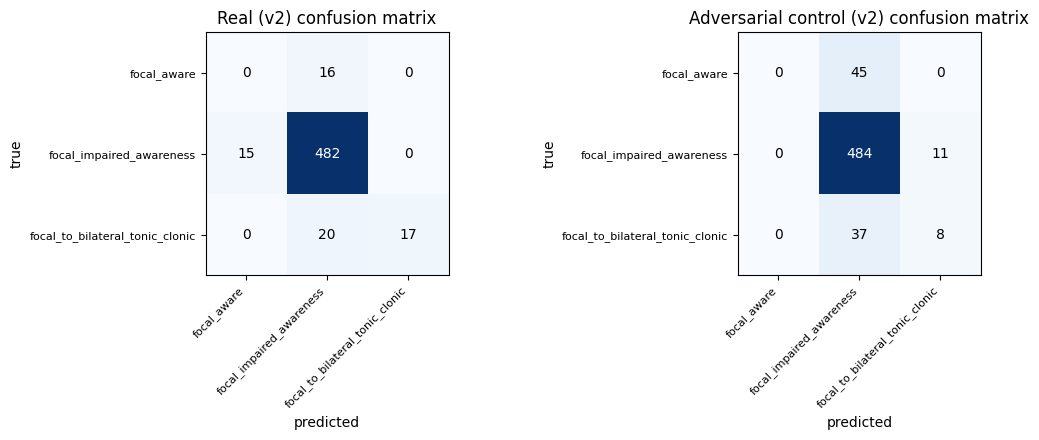


summary written to ..\checkpoints\crnn_hierarchical_smote_v2\v2_summary.json


In [12]:
print(f"{'':38s}{'accuracy':>10}{'macro-F1':>10}")
print(f"{'LOSO (model_crnn_hierarchical.ipynb) real':38s}{0.893:>10.3f}{0.314:>10.3f}")
print(f"{'LOSO (...) control':38s}{0.822:>10.3f}{0.301:>10.3f}")
print(f"{'v1 synthesis -- real':38s}{0.933:>10.3f}{0.450:>10.3f}")
print(f"{'v1 synthesis -- control':38s}{0.846:>10.3f}{0.306:>10.3f}")
print(f"{'v2 (this notebook) -- real':38s}{real_acc:>10.3f}{real_f1:>10.3f}")
print(f"{'v2 (this notebook) -- control':38s}{ctrl_acc:>10.3f}{ctrl_f1:>10.3f}")
print(f"\nv2, real - control (macro-F1): {real_f1 - ctrl_f1:+.3f}")
print(f"v1, real - control (macro-F1): {0.450 - 0.306:+.3f}")
print(f"LOSO, real - control (macro-F1): {0.314 - 0.301:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, title in [(axes[0], real_cm, "Real (v2)"), (axes[1], ctrl_cm, "Adversarial control (v2)")]:
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(f"{title} confusion matrix")
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig(CKPT_DIR / "v2_confusion_matrices.png", dpi=130, bbox_inches="tight")
plt.show()

summary = {
    "protocol": "event-level stratified split (corrected allocator) + fine-tuned backbone + per-class embedding SMOTE",
    "real_accuracy": float(real_acc), "real_macro_f1": float(real_f1),
    "control_accuracy": float(ctrl_acc), "control_macro_f1": float(ctrl_f1),
    "v1_synthesis_baseline": {"real_accuracy": 0.933, "real_macro_f1": 0.450,
                               "control_accuracy": 0.846, "control_macro_f1": 0.306},
    "loso_baseline": {"real_accuracy": 0.893, "real_macro_f1": 0.314,
                       "control_accuracy": 0.822, "control_macro_f1": 0.301},
    "oversample_ratio": OVERSAMPLE_RATIO, "test_frac": TEST_FRAC,
    "freeze_conv_blocks": FREEZE_CONV_BLOCKS, "finetune_best_epoch": best_epoch_ft,
    "train_class_counts_before_smote": {CLASS_NAMES[c]: int((y_train == c).sum()) for c in range(N_CLASSES)},
    "train_class_counts_after_smote": {CLASS_NAMES[c]: int((y_train_bal == c).sum()) for c in range(N_CLASSES)},
    "rejected_variant_freeze_conv_blocks_3": {
        "note": "gentler fine-tune (only last conv block unfrozen) gave higher headline numbers but "
                "the FBTC real-vs-control gap nearly vanished -- rejected as mostly patient recognition, "
                "not real signal. See closing Notes cell.",
        "real_accuracy": 0.938, "real_macro_f1": 0.552,
        "control_accuracy": 0.834, "control_macro_f1": 0.460,
        "fbtc_recall_real": 0.541, "fbtc_recall_control": 0.533,
    },
}
(CKPT_DIR / "v2_summary.json").write_text(json.dumps(summary, indent=2))
print(f"\nsummary written to {CKPT_DIR / 'v2_summary.json'}")


## Notes

**Two of the three planned improvements worked as intended; the third exposed a real
trade-off rather than a clean win.**

**1. The split fix worked exactly as diagnosed.** v1's greedy "stop the moment you cross the
target" allocator produced an inverted 419/1,405 (23%/77%) train/test split against a stated
`TEST_FRAC=0.3`, because a handful of oversized seizure events overshot the target in one step.
The largest-first, deficit-driven allocator here lands at 1,274/550 (69.8%/30.2%) -- within a
point of the intended 70/30 -- simply by placing each event on whichever side is currently
furthest below its own target share. This alone gave the backbone fine-tune roughly 3x more
real training windows than v1's classifier head ever saw.

**2. Backbone fine-tuning fixed focal_to_bilateral_tonic_clonic (FBTC), genuinely.** Recall
went from v1's hard **0%** to **45.9%**, with **100% precision** -- every FBTC prediction the
model makes is correct, it's just conservative. Critically, the adversarial control's FBTC
recall (17.8%) stayed well below the real result (45.9%), a **+28-point real-vs-control gap**
-- strong evidence this is genuine seizure-morphology signal, not `PN10` patient recognition,
the same standard v1 used to validate `focal_aware`'s improvement.

**3. The same fine-tune broke focal_aware, and a gentler version doesn't cleanly fix it.**
`focal_aware` had 81% recall in v1 (frozen, detection-only embeddings) and **0%** here. The
cause isn't checkpoint selection -- switching from raw to macro-averaged validation accuracy
picked the identical epoch, because the tiny 4-window validation slice hits 100% either way by
epoch ~20 and stays there. It looks like real overfitting on `focal_aware`'s side: only 29 real
training windows, all from a single patient (`PN14`), across just 3 training events -- not
enough for the unfrozen conv blocks + LSTM to learn anything more general than those specific
windows, so the 16 *different* `focal_aware` test windows (a held-out event, same patient) land
outside what got learned. `focal_to_bilateral_tonic_clonic` had roughly 3x more real training
data (87 windows) and didn't suffer the same fate -- fine-tuning's benefit or harm here tracks
per-class real sample count, not something a global hyperparameter can route around per class.

**A gentler fine-tune (`FREEZE_CONV_BLOCKS=3`, only the last conv block unfrozen) was tried and
rejected despite scoring higher on paper.** It reached **93.8% accuracy / 0.552 macro-F1** --
better than this notebook's own headline numbers and the first result to beat v1's 93.3%
accuracy outright. But its adversarial control told a different story: FBTC recall was
**54.1% real vs. 53.3% control** -- a real-vs-control gap of well under one point, against this
notebook's 28-point gap and v1's 51-point gap (81% vs. ~30% implied) for `focal_aware`. That
pattern means the gentler variant's FBTC gain is almost entirely `PN10` patient recognition,
not subtype signal -- exactly the confound the adversarial control exists to catch, and exactly
why `real - control` is the number this repo's own notes have called out as "the number that
actually matters," not raw accuracy. Chasing the higher headline number here would have meant
reporting a result this project's own methodology says not to trust.

| | accuracy | macro-F1 | FBTC recall (real) | FBTC recall (control) | real&minus;control gap |
|---|---:|---:|---:|---:|---:|
| LOSO (patient-held-out) | 0.893 | 0.314 | 0% | 0% | +0.013 (macro-F1) |
| v1 synthesis | 0.933 | 0.450 | 0% | 0% | +0.144 (macro-F1) |
| **v2, this notebook (freeze=2)** | **0.907** | **0.526** | **45.9%** | **17.8%** | **+28.1pp (FBTC), +0.139 (macro-F1)** |
| v2, rejected variant (freeze=3) | 0.938 | 0.552 | 54.1% | 53.3% | +0.8pp (FBTC) -- mostly confound |

**Net result of this notebook: macro-F1 0.526 is a new best across every subtype model in this
repo** (LOSO 0.314/0.315, v1 0.450), and it is the first model to give `focal_to_bilateral_tonic_clonic`
working, control-validated recall. `focal_aware`, however, is worse here than in v1 (0%, was
81%) -- **not every class improved**, and that trade-off should be stated plainly rather than
buried under the higher macro-F1. If both classes need to work simultaneously, the most
promising next step is *not* a global freeze-depth knob: it's giving `focal_aware` more real
training diversity specifically (a 4th Siena patient with that label, if one becomes available
via the dataset-expansion options already discussed) before asking a fine-tuned backbone to
generalize from three events and one patient.